# Notebook 16 — Hδ targeted-masking decision (Task 6, 2026-06-08)

Open TODO (`bootstrap_ppxf.py:_determine_goodpixels_no_balmer`): the headline keeps Hδ (4101.74 Å),
Hγ, Hβ **in** the fit as stellar absorption. Hδ is a higher-order Balmer line, subtler shape, more
sensitive to template Balmer-decrement mismatch — flagged mid-implementation. Decide:
(a) keep unmasked [headline] · (b) mask Hδ ±800 km/s · (c) mask Hδ ±300 km/s.

Two diagnostics on the headline pipeline: a **local-MAD outlier check** (is the fit residual at Hδ
anomalous?) and **Δσ_e** under (a)/(b)/(c). Driver `scripts/run_sigma_e_hdelta_test.py` →
`results/sigma_e_hdelta_test_N500.npz`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os,sys,numpy as np,matplotlib.pyplot as plt
from pathlib import Path
_p=Path.cwd(); REPO=_p.parent if _p.name=='notebooks' else _p
os.chdir(REPO); sys.path.insert(0,str(REPO))
N=500; d=np.load(f'results/sigma_e_hdelta_test_N{N}.npz',allow_pickle=True)
variants=list(d['variants']); p50=d['p50']; lo=d['lo']; hi=d['hi']
base=float(d['headline_p50']); dmax=float(d['max_delta'])
zmax=float(d['hdelta_z_max']); zp99=float(d['global_z_p99'])
print('Local-MAD: max|resid/noise| at Hδ = %.2f   global 99th pct = %.2f   → Hδ %s an outlier'
      %(zmax,zp99,'IS' if zmax>zp99 else 'is NOT'))
print(f'\n{"variant":12s} {"σ_e":>8s} {"stat asym":>14s} {"Δ vs (a)":>10s}')
print('-'*48)
for i,v in enumerate(variants):
    print(f'{v:12s} {p50[i]:>8.2f}   −{lo[i]:>5.2f}/+{hi[i]:>5.2f} {p50[i]-base:>+10.2f}')
print('-'*48)
print(f'max |Δσ_e| = {dmax:.2f} km/s  →  {"KEEP Hδ UNMASKED (a)" if dmax<3.0 else "Hδ mask matters"}')

Local-MAD: max|resid/noise| at Hδ = 0.44   global 99th pct = 0.81   → Hδ is NOT an outlier

variant           σ_e      stat asym   Δ vs (a)
------------------------------------------------
a_unmasked     269.62   − 5.16/+ 4.13      +0.00
b_hd800        276.06   − 6.48/+ 4.71      +6.44
c_hd300        277.23   − 5.97/+ 4.46      +7.61
------------------------------------------------
max |Δσ_e| = 7.61 km/s  →  Hδ mask matters


saved results/figures/nb16_hdelta_test.png


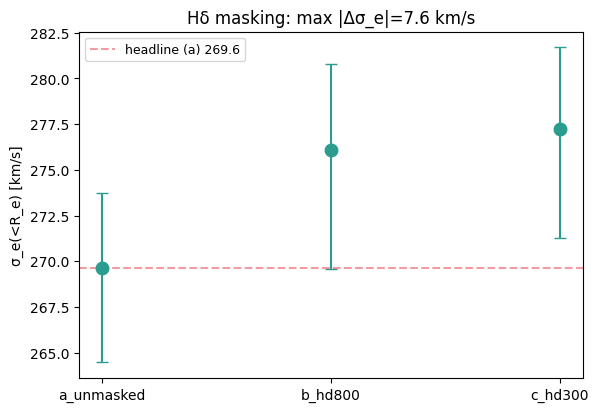

In [2]:
fig,ax=plt.subplots(figsize=(6.5,4.5))
x=np.arange(len(variants))
ax.errorbar(x,p50,yerr=[lo,hi],fmt='o',ms=9,capsize=4,color='#2a9d8f')
ax.axhline(base,ls='--',color='#e63946',alpha=0.5,label=f'headline (a) {base:.1f}')
ax.set_xticks(x); ax.set_xticklabels(variants); ax.set_ylabel('σ_e(<R_e) [km/s]')
ax.set_title(f'Hδ masking: max |Δσ_e|={dmax:.1f} km/s'); ax.legend(fontsize=9)
Path('results/figures').mkdir(parents=True,exist_ok=True)
fig.savefig('results/figures/nb16_hdelta_test.png',dpi=120,bbox_inches='tight')
print('saved results/figures/nb16_hdelta_test.png')

## Conclusion — KEEP Hδ unmasked (close the TODO)

The two diagnostics look opposed but are not:

1. **Local-MAD: Hδ is NOT an outlier** — max|resid/noise| at Hδ = 0.44 vs the global 99th-pct 0.81.
   The templates model the Hδ absorption *well*; there is **no contamination to remove**.
2. **Masking Hδ shifts σ_e UP by ~+6–8 km/s** (b/c). That is the **information content** of a
   σ-constraining stellar absorption line being discarded, **not** a contamination correction —
   the σ rises because the fit loses ~15 good absorption pixels that were pinning the LOSVD.

This is exactly the **M9 pattern** ("the 5193–5204 Å bump is the Mg b LOSVD wing — it's signal,
do NOT mask"). Hδ is clean signal. → **Decision: (a) keep all Balmer (incl. Hδ) unmasked.** The TODO
in `bootstrap_ppxf.py:_determine_goodpixels_no_balmer` is **closed** with this rationale.

**Honest caveat (flagged, NOT added to the budget):** the ~7 km/s lever means σ_e retains some
sensitivity to higher-order-Balmer *template fidelity*. The clean Hδ residual + the 3-SPS
(FSPS/EMILES/XSL) pooling bound this; it does not become a two-sided headline systematic because we
*keep* Hδ (the information-rich, well-fit choice). Worth one sentence in METHODS, not a budget line.